# ACCESS-OM3 MC 100km JRA RYF Scaling

End-to-end pipeline generating scaling plots for [ACCESS-OM3 MC 100km JRA RYF configuration](https://github.com/ACCESS-NRI/access-om3-configs/tree/dev-MC_100km_jra_ryf).

In [1]:
%load_ext autoreload
%autoreload 2

## Package versions

In [2]:
from importlib.metadata import version
for pkg in ("access.config.utils", "access.profiling",):
    print(f"{pkg}: {version(pkg)}")

access.config.utils: 0.3.dev7+g6230bd6c2
access.profiling: 0.2.dev30+g7e92d9d46.d20260916


## Setup
The following variables control where the configurations and model run outputs are saved.

In [3]:
## Imports
from pathlib import Path

from access.config.parallel_domain import Domain
from access.profiling.access_models import OM3Profiling, OM3Configuration

test_path = f"/scratch/tm70/model_scaling/ACCESS-OM3/dev-MC_100km_jra_ryf"
archive_path = f"/g/data/tm70/model_scaling/ACCESS-OM3/dev-MC_100km_jra_ryf/archive"

GLOBAL_GRID = Domain(shape=(360, 324))
OM3_MC_100KM = OM3Configuration(
    name="MC-100km",
    ocean=GLOBAL_GRID,
    sea_ice=GLOBAL_GRID,
    atmosphere=GLOBAL_GRID,
    runoff=GLOBAL_GRID,
)

om3_profiling = OM3Profiling(work_dir=Path(test_path), archive_dir=Path(archive_path), configuration=OM3_MC_100KM)
om3_profiling.set_control(repository="https://github.com/ACCESS-NRI/access-om3-configs.git", commit="dev-MC_100km_jra_ryf")

## Generate experiments

We will perform a simple scaling study, varying the total number of nodes used over `[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0]`. We will search for different layouts that closely match a scaled 4-node released piControl config.

In [4]:
from access.config.parallel_allocation_strategies import RootAllocation, FreeAllocation, WholeRangeAllocation
from access.config.parallel_constraints import SubdomainAspectRatioConstraint, RankRatioGroupConstraint, MaxWastedCoreFractionConstraint, EqualCoresGroupConstraint

# Define how the cores should be allocated to the components
allocation_strategy = RootAllocation(
    subcomponents={
        "ocn": FreeAllocation(min_core_fraction=0.85,),
        "shared": FreeAllocation(min_core_fraction=0.05,
            subcomponents={
                "ice": WholeRangeAllocation(local_constraints=(SubdomainAspectRatioConstraint(max_ratio=1.5),),),
                "cpl": WholeRangeAllocation(),
                "rof": WholeRangeAllocation(),
                "atm": WholeRangeAllocation(),
            },
        ),
    },
    local_constraints=(MaxWastedCoreFractionConstraint(max_fraction=0.01),),
#        group_constraints=(
#        RankRatioGroupConstraint(name_a="ocn", name_b="shared", min_ratio=1),
#        RankRatioGroupConstraint(name_a="shared", name_b="ocn", min_ratio=1),
#    ),
)


#from access.config.parallel_layouts import iter_layouts


#layouts = list(iter_layouts(OM3_MC_100KM.parallel_component, 7*48, allocations=allocation_strategy))
#print(len(layouts))
#for layout in layouts:
#    print(layout.sub_layouts[1])
#    print(layout.sub_layouts[0])
#    print("\n")



In [5]:
###### Generate the configuration and write to file
num_nodes_list = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0]
control_options = {
            "config.yaml": {
                "manifest": {"reproduce": {"exe": False}},
                "postscript": "REMOVE",
                "mem": "REMOVE",
            }
}

def walltime(num_nodes):
    return 4 * 4.0/num_nodes # use a 4 hrs time for 4-node runs, and then scale linearly

om3_profiling.generate_scaling_experiments(num_nodes_list=num_nodes_list, control_options=control_options, cores_per_node=48, walltime=walltime, allocations=allocation_strategy)

-- Test directory /scratch/tm70/model_scaling/ACCESS-OM3/dev-MC_100km_jra_ryf already exists!
-- Test dir: /scratch/tm70/model_scaling/ACCESS-OM3/dev-MC_100km_jra_ryf/config already exists, hence not cloning https://github.com/ACCESS-NRI/access-om3-configs.git
Checked out branch: ctrl
laboratory path:  /scratch/tm70/mo1833/access-om3
binary path:  /scratch/tm70/mo1833/access-om3/bin
input path:  /scratch/tm70/mo1833/access-om3/input
work path:  /scratch/tm70/mo1833/access-om3/work
archive path:  /scratch/tm70/mo1833/access-om3/archive
Metadata and UUID generation is disabled. Experiment name used for archival: config
No prior restart path provided. Skip adding parent branch time to metadata.
Removed archive symlink to /scratch/tm70/mo1833/access-om3/archive/config
Added archive symlink to /scratch/tm70/mo1833/access-om3/archive/config
Removed work symlink to /scratch/tm70/mo1833/access-om3/work/config
Added work symlink to /scratch/tm70/mo1833/access-om3/work/config
-- Branch om3-layou

## Run experiments

Next we run the experiments

In [16]:
om3_profiling.run_experiments()

* Current Branch: om3-layout_MC-100km_atm_42_cpl_42_ice_7x6_ocn_244_rof_42
    No metadata file found
Branch: ctrl
    No metadata file found
Branch: main
    No config file found
Branch: om3-layout_MC-100km_atm_12_cpl_12_ice_3x4_ocn_131_rof_12
    No metadata file found
Branch: om3-layout_MC-100km_atm_12_cpl_12_ice_3x4_ocn_132_rof_12
    No metadata file found
Branch: om3-layout_MC-100km_atm_12_cpl_12_ice_3x4_ocn_179_rof_12
    No metadata file found
Branch: om3-layout_MC-100km_atm_12_cpl_12_ice_3x4_ocn_180_rof_12
    No metadata file found
Branch: om3-layout_MC-100km_atm_12_cpl_12_ice_3x4_ocn_226_rof_12
    No metadata file found
Branch: om3-layout_MC-100km_atm_12_cpl_12_ice_3x4_ocn_227_rof_12
    No metadata file found
Branch: om3-layout_MC-100km_atm_12_cpl_12_ice_3x4_ocn_228_rof_12
    No metadata file found
Branch: om3-layout_MC-100km_atm_12_cpl_12_ice_3x4_ocn_84_rof_12
    No metadata file found
Branch: om3-layout_MC-100km_atm_12_cpl_12_ice_4x3_ocn_131_rof_12
    No metadata file

## Parsing and plotting experiment results

In [6]:
from access.profiling.metrics import tmax

# Parse the data
om3_profiling.parse_profiling_data()

# Get the best (fastest) layouts for each node count
best_experiments = om3_profiling.select_best_experiments(component="payu",region="payu_model_run_duration_seconds", metric=tmax)
best_experiments

Experiment 'om3-layout_MC-100km_atm_6_cpl_6_ice_3x2_ocn_42_rof_6' is not completed (status: FAILED). Skipping parsing profiling data.
Experiment 'om3-layout_MC-100km_atm_25_cpl_25_ice_5x5_ocn_167_rof_25' is not completed (status: FAILED). Skipping parsing profiling data.
Experiment 'om3-layout_MC-100km_atm_12_cpl_12_ice_3x4_ocn_179_rof_12' is not completed (status: FAILED). Skipping parsing profiling data.
Experiment 'om3-layout_MC-100km_atm_12_cpl_12_ice_4x3_ocn_179_rof_12' is not completed (status: FAILED). Skipping parsing profiling data.
Experiment 'om3-layout_MC-100km_atm_24_cpl_24_ice_6x4_ocn_167_rof_24' is not completed (status: FAILED). Skipping parsing profiling data.
Experiment 'om3-layout_MC-100km_atm_12_cpl_12_ice_3x4_ocn_227_rof_12' is not completed (status: FAILED). Skipping parsing profiling data.
Experiment 'om3-layout_MC-100km_atm_12_cpl_12_ice_4x3_ocn_227_rof_12' is not completed (status: FAILED). Skipping parsing profiling data.
Experiment 'om3-layout_MC-100km_atm_16

['om3-layout_MC-100km_atm_4_cpl_4_ice_2x2_ocn_44_rof_4',
 'om3-layout_MC-100km_atm_15_cpl_15_ice_5x3_ocn_81_rof_15',
 'om3-layout_MC-100km_atm_15_cpl_15_ice_5x3_ocn_128_rof_15',
 'om3-layout_MC-100km_atm_24_cpl_24_ice_6x4_ocn_168_rof_24',
 'om3-layout_MC-100km_atm_35_cpl_35_ice_7x5_ocn_204_rof_35',
 'om3-layout_MC-100km_atm_42_cpl_42_ice_7x6_ocn_245_rof_42',
 'om3-layout_MC-100km_atm_54_cpl_54_ice_9x6_ocn_328_rof_54']

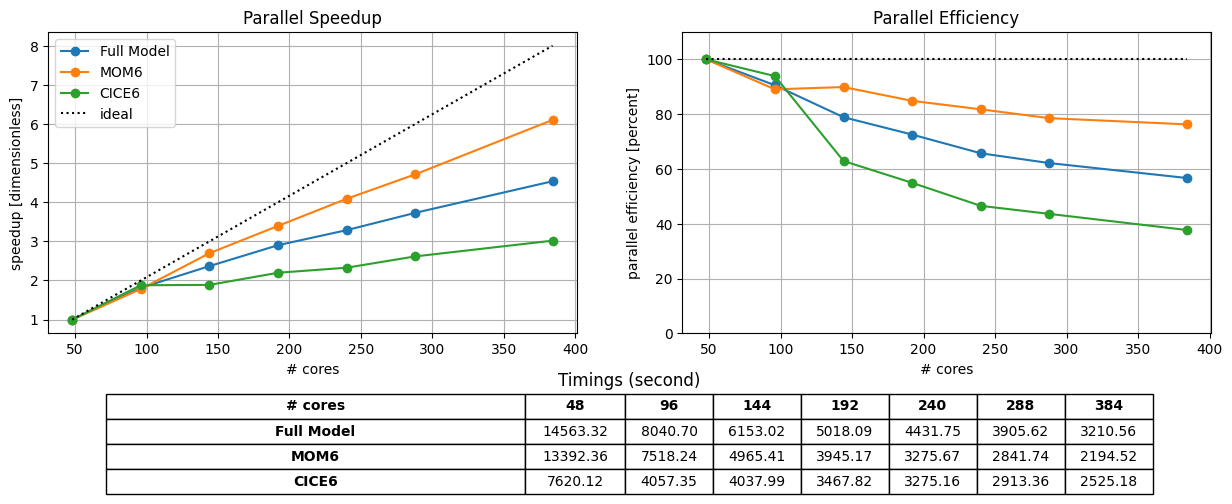

In [7]:
# Plot the scaling data, using only the best experiments
fig = om3_profiling.plot_scaling_data(
    components=["payu", "MOM6", "CICE6"],
    regions=[
        ["payu_model_run_duration_seconds"],
        ["Ocean"],
        ["Total"],
    ],
    metric=tmax,
    region_relabel_map={
        "payu_model_run_duration_seconds": "Full Model",
        "Ocean": "MOM6",
        "Total": "CICE6",
    },
    experiments=best_experiments,
    xlabel="# cores",
)

## Summary

We have presented the strong scaling results for the [piControl v2.0 configuration](https://github.com/ACCESS-NRI/access-esm1.6-configs/releases/tag/release-piControl-2.0) of ESM 1.6. The underlying components are UM7.3 for atmosphere, MOM5 for ocean, and CICE5 for the ice models. These three components run concurrently over the course of the experiment, with the atmosphere and ice cores responsible for exchanging data (i.e., MPI operations between all three components). The released configuration for ESM1.6 uses 5-nodes on the normalsr queue with sapphirerapids cpus, where each node contains 104 cores.

We have varied the number of nodes between 1 and 8, and for each case, we have tested several options with different partitioning of the total number of available cores between the three components. In the plots above, we have presented the best performing configuration for each case. For the two top plots, the x-axis is the total number of cores used in the configuration, and the y-axis is speedup relative to the single node config (left) and computational efficiency relative to the single node config (right). The plot on the left shows that the ESM1.6 model shows near-ideal scaling up to 4 nodes, and then performance drops off and plateaus for higher node-counts. We observe a similar effect in the computational efficiency as well - the efficiency is above 90% for all nodes up to 5, but then drops off for higher node counts. UM/CICE dominate the scaling results and it is to be expected that any code will plateau when the serial part (potentially from synchronisation) starts to dominate (Amdahl's law). In addition, due to the concurrent running of the three components, we expect that this drop-off is partially from imperfect loadbalancing, and further investigation is required to improve the scaling for running ESM1.6 on >= 6 nodes. The table shows the raw data from the runs corresponding to each of the components, and the overall model runtime. The columns represent 1, 2, 3, 4, 5, 6, and 8 node configs.

# Archive

Archive experiments.

In [8]:
om3_profiling.archive_experiments()

Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/dev-MC_100km_jra_ryf/archive/om3-layout_MC-100km_atm_54_cpl_54_ice_9x6_ocn_329_rof_54.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/dev-MC_100km_jra_ryf/archive/om3-layout_MC-100km_atm_36_cpl_36_ice_6x6_ocn_348_rof_36.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/dev-MC_100km_jra_ryf/archive/om3-layout_MC-100km_atm_24_cpl_24_ice_6x4_ocn_215_rof_24.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/dev-MC_100km_jra_ryf/archive/om3-layout_MC-100km_atm_42_cpl_42_ice_7x6_ocn_341_rof_42.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/dev-MC_100km_jra_ryf/archive/om3-layout_MC-100km_atm_56_cpl_56_ice_8x7_ocn_327_rof_56.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/dev-MC_100km_jra_r